In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('supplier_risk.csv')
df

,Supplier_ID,Year,Financial_Stability_Score,Delivery_Performance_Score,Quality_Compliance_Score,Regulatory_Adherence_Score,Sustainability_Score,Past_Risk_Level,ERP_Transactions,Incidents_Count,MCDM_Score,Risk_Category
0,52,2025,0.43,0.87,0.80,0.78,0.37,0.46,422,3,0.66,Medium
1,24,2023,0.31,0.98,0.92,0.68,0.43,0.18,363,11,0.67,Medium
2,89,2021,0.67,0.64,0.52,0.99,0.46,0.09,495,18,0.66,Medium
3,55,2024,0.71,0.43,0.80,0.67,0.35,0.95,365,13,0.62,Medium
4,9,2022,0.37,0.81,0.72,0.65,0.65,0.03,255,16,0.62,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
1795,18,2025,0.73,0.83,0.69,0.87,0.80,0.94,332,9,0.78,High
1796,83,2021,0.91,0.88,0.79,0.63,0.49,0.30,469,4,0.79,High
1797,39,2025,0.42,0.92,0.75,0.70,0.78,0.89,464,16,0.69,Medium
1798,87,2025,0.83,0.44,0.61,0.79,0.72,0.34,282,2,0.67,Medium


In [4]:
df.shape

(1800, 12)

In [5]:
df.columns

Index(['Supplier_ID', 'Year', 'Financial_Stability_Score',
       'Delivery_Performance_Score', 'Quality_Compliance_Score',
       'Regulatory_Adherence_Score', 'Sustainability_Score', 'Past_Risk_Level',
       'ERP_Transactions', 'Incidents_Count', 'MCDM_Score', 'Risk_Category'],
      dtype='object')

In [6]:
df.info

<bound method DataFrame.info of       Supplier_ID  Year  Financial_Stability_Score  \
0              52  2025                       0.43   
1              24  2023                       0.31   
2              89  2021                       0.67   
3              55  2024                       0.71   
4               9  2022                       0.37   
...           ...   ...                        ...   
1795           18  2025                       0.73   
1796           83  2021                       0.91   
1797           39  2025                       0.42   
1798           87  2025                       0.83   
1799           10  2021                       0.40   

      Delivery_Performance_Score  Quality_Compliance_Score  \
0                           0.87                      0.80   
1                           0.98                      0.92   
2                           0.64                      0.52   
3                           0.43                      0.80   
4        

In [7]:
print("Missing value:")
print(df.isnull().sum())

Missing value:
Supplier_ID                   0
Year                          0
Financial_Stability_Score     0
Delivery_Performance_Score    0
Quality_Compliance_Score      0
Regulatory_Adherence_Score    0
Sustainability_Score          0
Past_Risk_Level               0
ERP_Transactions              0
Incidents_Count               0
MCDM_Score                    0
Risk_Category                 0
dtype: int64


In [8]:
df.columns= df.columns.str.strip()
df.duplicated().sum()

np.int64(0)

In [9]:
df=df.drop_duplicates()

In [10]:
print("===== OVERVIEW =====")
print("Total number of records:", len(df))
print("Total number of suppliers:", df["Supplier_ID"].nunique())
print("Rish category distribution:")
print("Average values of main indicators:")
print("Average Delivery Performance Score:",round(df["Delivery_Performance_Score"].mean(),2))
print("Average Financial Stability Score:",round(df["Financial_Stability_Score"].mean(),2))
print("Average Incidents Count:",round(df["Incidents_Count"].mean(),2))
print("Average MCDM Score:",round(df["MCDM_Score"].mean(),2))


===== OVERVIEW =====
Total number of records: 1800
Total number of suppliers: 100
Rish category distribution:
Average values of main indicators:
Average Delivery Performance Score: 0.7
Average Financial Stability Score: 0.65
Average Incidents Count: 9.6
Average MCDM Score: 0.7


In [11]:
risk_summary= df.groupby("Risk_Category")[[
    "Financial_Stability_Score",
    "Delivery_Performance_Score",
    "Quality_Compliance_Score",
    "Regulatory_Adherence_Score",
    "Sustainability_Score",
    "Incidents_Count",
    "MCDM_Score"
]].mean().round(2)
print("====== AVERAGE VALUES BY RISK CATEGORY=====")
print(risk_summary)

====== AVERAGE VALUES BY RISK CATEGORY=====
               Financial_Stability_Score  Delivery_Performance_Score  \
Risk_Category                                                          
High                                0.77                        0.78   
Medium                              0.53                        0.62   

               Quality_Compliance_Score  Regulatory_Adherence_Score  \
Risk_Category                                                         
High                               0.78                        0.81   
Medium                             0.71                        0.78   

               Sustainability_Score  Incidents_Count  MCDM_Score  
Risk_Category                                                     
High                           0.69             9.49        0.77  
Medium                         0.60             9.71        0.63  


In [12]:
year_summary=df.groupby("Year")[[
    "Delivery_Performance_Score",
    "Incidents_Count",
    "MCDM_Score"
]].mean().round(2)
print("===== YEAR SUMMARY =====")
print(year_summary)

===== YEAR SUMMARY =====
      Delivery_Performance_Score  Incidents_Count  MCDM_Score
Year                                                         
2021                        0.69             9.72        0.70
2022                        0.70             9.33        0.70
2023                        0.69             9.43        0.70
2024                        0.71             9.87        0.70
2025                        0.71             9.66        0.71


In [13]:
top_incident_suppliers = (
    df.groupby("Supplier_ID")["Incidents_Count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("===== TOP 10 SUPPLIERS WITH HIGHEST INCIDENTS =====")
print(top_incident_suppliers)

# Suppliers with the lowest average delivery performance
lowest_delivery_suppliers = (
    df.groupby("Supplier_ID")["Delivery_Performance_Score"]
    .mean()
    .sort_values()
    .head(10)
)

print("===== TOP 10 SUPPLIERS WITH LOWEST DELIVERY PERFORMANCE =====")
print(lowest_delivery_suppliers)

# Suppliers with the lowest average MCDM score
lowest_mcdm_suppliers = (
    df.groupby("Supplier_ID")["MCDM_Score"]
    .mean()
    .sort_values()
    .head(10)
)

print("===== TOP 10 SUPPLIERS WITH LOWEST MCDM SCORE =====")
print(lowest_mcdm_suppliers)

===== TOP 10 SUPPLIERS WITH HIGHEST INCIDENTS =====
Supplier_ID
3     292
19    282
23    275
76    275
62    270
36    270
55    267
54    265
63    263
21    258
Name: Incidents_Count, dtype: int64
===== TOP 10 SUPPLIERS WITH LOWEST DELIVERY PERFORMANCE =====
Supplier_ID
85    0.600833
28    0.608889
76    0.613913
30    0.626923
29    0.634000
81    0.638000
86    0.638333
42    0.641765
1     0.642308
90    0.644400
Name: Delivery_Performance_Score, dtype: float64
===== TOP 10 SUPPLIERS WITH LOWEST MCDM SCORE =====
Supplier_ID
45    0.652800
28    0.662222
18    0.662222
76    0.662609
88    0.667647
30    0.667692
67    0.669048
82    0.669375
24    0.670476
6     0.671333
Name: MCDM_Score, dtype: float64


In [14]:
# OPTIONAL BUSINESS RULE FLAG
def action_flag(row):
    if row["Incidents_Count"] >= 8 and row["Delivery_Performance_Score"] < 60:
        return "Review Immediately"
    elif row["Incidents_Count"] >= 5:
        return "Monitor Closely"
    else:
        return "Normal"

df["Action_Flag"] = df.apply(action_flag, axis=1)

print("===== ACTION FLAG SAMPLE =====")
print(df[["Supplier_ID", "Incidents_Count", "Delivery_Performance_Score", "Action_Flag"]].head())


===== ACTION FLAG SAMPLE =====
   Supplier_ID  Incidents_Count  Delivery_Performance_Score  \
0           52                3                        0.87   
1           24               11                        0.98   
2           89               18                        0.64   
3           55               13                        0.43   
4            9               16                        0.81   

          Action_Flag  
0              Normal  
1  Review Immediately  
2  Review Immediately  
3  Review Immediately  
4  Review Immediately  


In [15]:
plt.style.use("default")
plt.close("all")
risk_colors = {
    "High": "#E76F51",
    "Medium": "#457B9D",
    "Low": "#2A9D8F"
}

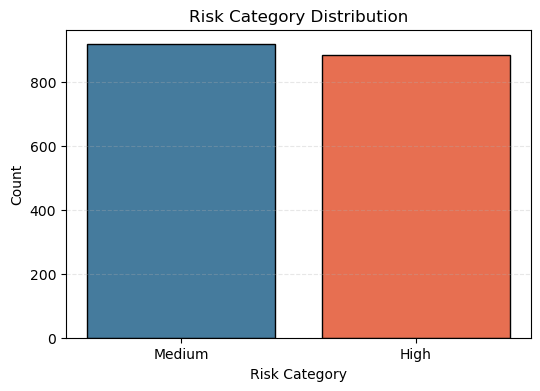

In [16]:
risk_counts = df["Risk_Category"].value_counts()
colors = [risk_colors.get(cat, "#999999") for cat in risk_counts.index]

plt.figure(figsize=(6,4))
plt.bar(risk_counts.index, risk_counts.values, color=colors, edgecolor="black")
plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


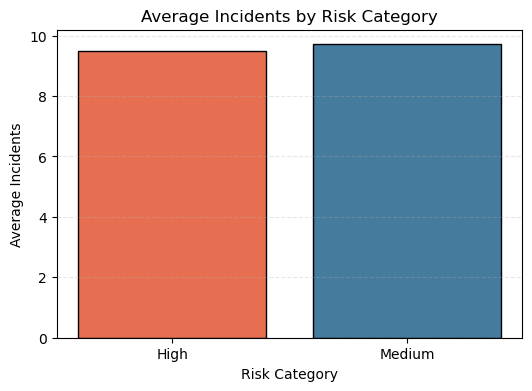

In [17]:
avg_incidents = df.groupby("Risk_Category")["Incidents_Count"].mean()
colors = [risk_colors.get(cat, "#999999") for cat in avg_incidents.index]

plt.figure(figsize=(6,4))
plt.bar(avg_incidents.index, avg_incidents.values, color=colors, edgecolor="black")
plt.title("Average Incidents by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Incidents")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


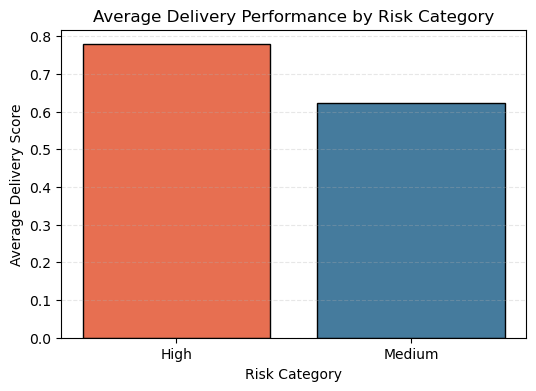

In [18]:
avg_delivery = df.groupby("Risk_Category")["Delivery_Performance_Score"].mean()
colors = [risk_colors.get(cat, "#999999") for cat in avg_delivery.index]
plt.figure(figsize=(6,4))
plt.bar(avg_delivery.index, avg_delivery.values, color=colors, edgecolor="black")
plt.title("Average Delivery Performance by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Delivery Score")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

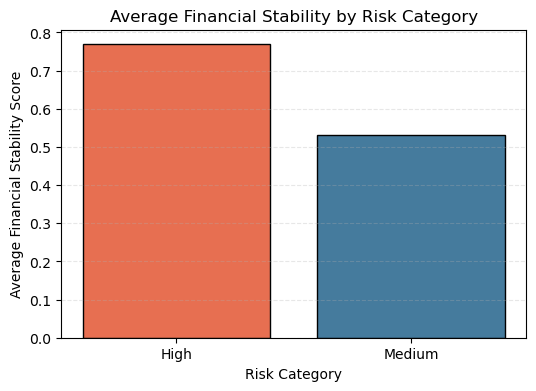

In [19]:
avg_finance = df.groupby("Risk_Category")["Financial_Stability_Score"].mean()
colors = [risk_colors.get(cat, "#999999") for cat in avg_finance.index]
plt.figure(figsize=(6,4))
plt.bar(avg_finance.index, avg_finance.values, color=colors, edgecolor="black")
plt.title("Average Financial Stability by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Financial Stability Score")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

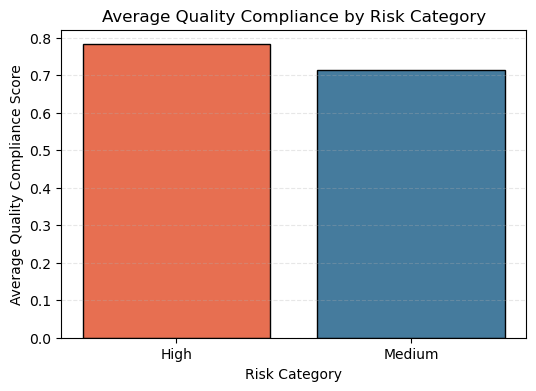

In [20]:
avg_quality = df.groupby("Risk_Category")["Quality_Compliance_Score"].mean()
colors = [risk_colors.get(cat, "#999999") for cat in avg_quality.index]

plt.figure(figsize=(6,4))
plt.bar(avg_quality.index, avg_quality.values, color=colors, edgecolor="black")
plt.title("Average Quality Compliance by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Quality Compliance Score")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

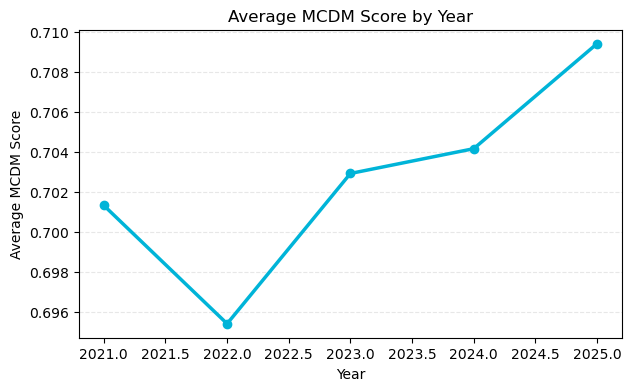

In [21]:
avg_mcdm_year = df.groupby("Year")["MCDM_Score"].mean()
plt.figure(figsize=(7,4))
plt.plot(avg_mcdm_year.index, avg_mcdm_year.values, marker="o", linewidth=2.5, color="#00B4D8")
plt.title("Average MCDM Score by Year")
plt.xlabel("Year")
plt.ylabel("Average MCDM Score")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_4424\3787254337.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


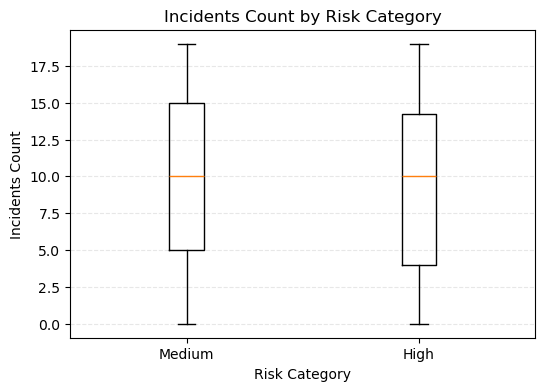

In [22]:
data_to_plot = [
    df[df["Risk_Category"] == category]["Incidents_Count"]
    for category in df["Risk_Category"].unique()
]

labels = df["Risk_Category"].unique()

plt.figure(figsize=(6,4))
plt.boxplot(data_to_plot, labels=labels)
plt.title("Incidents Count by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Incidents Count")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

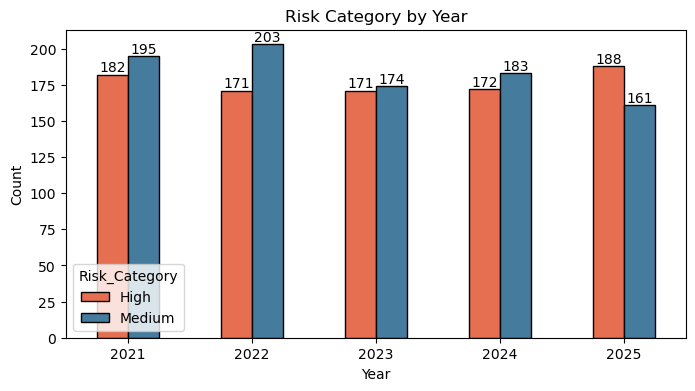

In [23]:
risk_year = df.groupby(["Year", "Risk_Category"]).size().unstack(fill_value=0)

ax = risk_year.plot(
    kind="bar",
    figsize=(8, 4),
    color=[risk_colors.get(col, "#999999") for col in risk_year.columns],
    edgecolor="black"
)

plt.title("Risk Category by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()